In [10]:
import os
import glob
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import kagglehub

# ==========================================
# 1. DOWNLOADING THE DATASET FROM KAGGLE
# ==========================================
print("⏳ Downloading dataset from Kaggle (this may take some time)...")
path = kagglehub.dataset_download("requiemonk/sentinel12-image-pairs-segregated-by-terrain")
print("✅ Path to downloaded files:", path)

# Let's print the root folders to understand the structure
print("\n📁 Directory structure in the downloaded dataset:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f"{indent}{os.path.basename(root)}/")
    subdirs = dirs[:3]
    if len(dirs) > 3:
        subdirs.append('...')

⏳ Downloading dataset from Kaggle (this may take some time)...
✅ Path to downloaded files: C:\Users\Artem\.cache\kagglehub\datasets\requiemonk\sentinel12-image-pairs-segregated-by-terrain\versions\1

📁 Directory structure in the downloaded dataset:
1/
    v_2/
        agri/
            s1/
            s2/
        barrenland/
            s1/
            s2/
        grassland/
            s1/
            s2/
        urban/
            s1/
            s2/


In [11]:
# ==========================================
# 2. FINAL AND RELIABLE PAIR COLLECTION
# ==========================================

all_s1_images = glob.glob(os.path.join(path, "**", "s1", "*.png"), recursive=True) + \
                glob.glob(os.path.join(path, "**", "s1", "*.jpg"), recursive=True)

print(f"\n🔍 Radar images found (s1): {len(all_s1_images)}")

data_pairs = []

for s1_path in all_s1_images:
    s1_norm = os.path.normpath(s1_path)
    
    # Split the path into directory and the filename itself
    # s1_dir  -> ...\v_2\agri\s1
    # s1_name -> ROIs1868_summer_s1_59_p10.png
    # (Note: context path shows Artem4ikPksh profile with similar local paths)
    s1_dir, s1_name = os.path.split(s1_norm)
    
    # Replace the FINAL folder 's1' with 's2' in the directory path
    # Now s2_dir -> ...\v_2\agri\s2
    s2_dir = os.path.join(os.path.dirname(s1_dir), "s2")
    
    # Scenario A: The filename in s2 changes its internal marker from '_s1_' to '_s2_'
    s2_name_variant_A = s1_name.replace("_s1_", "_s2_")
    s2_path_A = os.path.join(s2_dir, s2_name_variant_A)
    
    # Scenario B: The filename in s2 remains identical to s1
    s2_path_B = os.path.join(s2_dir, s1_name)
    
    # Check which variant actually exists on the disk
    final_s2_path = None
    if os.path.exists(s2_path_A):
        final_s2_path = s2_path_A
    elif os.path.exists(s2_path_B):
        final_s2_path = s2_path_B
        
    if final_s2_path:
        # Determine the terrain type (landscape)
        # s1_dir is ...\agri\s1, so we take the parent folder name
        landscape = os.path.basename(os.path.dirname(s1_dir)) 
        core_name = f"{landscape}_{s1_name}"
        
        data_pairs.append({
            "image_a": s1_norm,
            "image_b": final_s2_path,
            "core_id": core_name
        })

df = pd.DataFrame(data_pairs)
df = df.head(500)
print(f"📊 Successfully generated valid pairs for matching: {len(df)}")

csv_output_path = "sentinel_dataset_index.csv"
df.to_csv(csv_output_path, index=False)
print(f"💾 Index file successfully saved to: {csv_output_path}")


🔍 Radar images found (s1): 16000
📊 Successfully generated valid pairs for matching: 500
💾 Index file successfully saved to: sentinel_dataset_index.csv


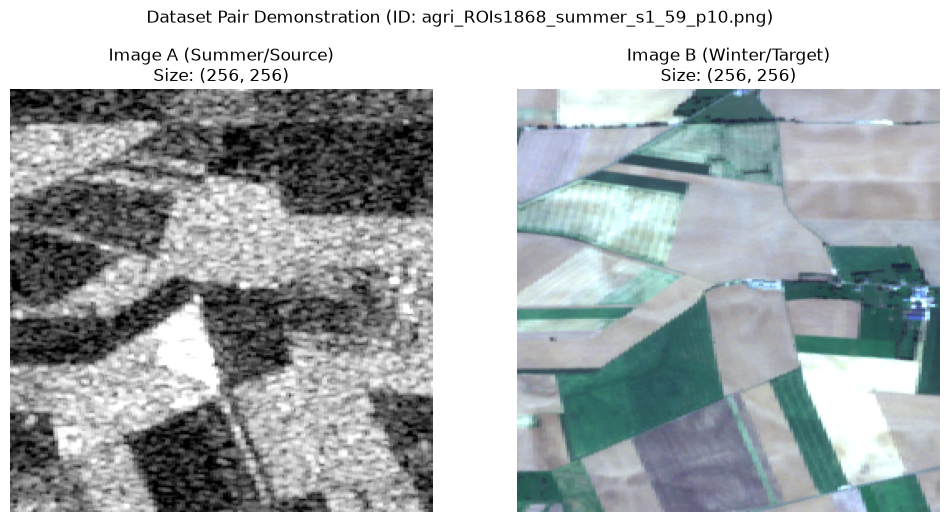

In [12]:
# ==========================================
# 3. VISUALIZATION OF THE FIRST PAIR FOR DEMONSTRATION
# ==========================================
if not df.empty:
    sample = df.iloc[0]
    
    img_a = cv2.imread(sample['image_a'])
    img_b = cv2.imread(sample['image_b'])
    
    # Convert BGR to RGB for correct rendering in Matplotlib
    img_a = cv2.cvtColor(img_a, cv2.COLOR_BGR2RGB)
    img_b = cv2.cvtColor(img_b, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_a)
    axes[0].set_title(f"Image A (Summer/Source)\nSize: {img_a.shape[:2]}")
    axes[0].axis('off')
    
    axes[1].imshow(img_b)
    axes[1].set_title(f"Image B (Winter/Target)\nSize: {img_b.shape[:2]}")
    axes[1].axis('off')
    
    plt.suptitle(f"Dataset Pair Demonstration (ID: {sample['core_id']})")
    plt.show()
else:
    print("❌ Failed to find matches to form pairs. Please check the directory structure of the downloaded dataset.")